In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [2]:
df = pd.read_csv("delhi_ncr_aqi_dataset.csv")
df

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201659,2025-12-31 23:00:00,2025-12-31,2025,12,31,23,Wednesday,0,winter,Ghaziabad,...,97.0,23.9,5.58,14.8,16.1,51,3.8,0.9,500,Severe
201660,2025-12-31 06:00:00,2025-12-31,2025,12,31,6,Wednesday,0,winter,Ghaziabad,...,119.2,26.9,5.34,12.1,9.8,95,3.2,1.2,500,Severe
201661,2025-12-31 12:00:00,2025-12-31,2025,12,31,12,Wednesday,0,winter,Ghaziabad,...,90.3,33.7,3.73,28.2,21.4,57,7.1,2.9,500,Severe
201662,2025-12-31 18:00:00,2025-12-31,2025,12,31,18,Wednesday,0,winter,Ghaziabad,...,170.7,20.9,6.98,22.9,15.4,51,6.8,1.2,500,Severe


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201664 entries, 0 to 201663
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      201664 non-null  object 
 1   date          201664 non-null  object 
 2   year          201664 non-null  int64  
 3   month         201664 non-null  int64  
 4   day           201664 non-null  int64  
 5   hour          201664 non-null  int64  
 6   day_of_week   201664 non-null  object 
 7   is_weekend    201664 non-null  int64  
 8   season        201664 non-null  object 
 9   city          201664 non-null  object 
 10  station       201664 non-null  object 
 11  latitude      201664 non-null  float64
 12  longitude     201664 non-null  float64
 13  pm25          201664 non-null  float64
 14  pm10          201664 non-null  float64
 15  no2           201664 non-null  float64
 16  so2           201664 non-null  float64
 17  co            201664 non-null  float64
 18  o3  

In [4]:
df.select_dtypes(object)

,datetime,date,day_of_week,season,city,station,aqi_category
0,2020-01-01 06:00:00,2020-01-01,Wednesday,winter,Delhi,"Anand Vihar, Delhi",Severe
1,2020-01-01 12:00:00,2020-01-01,Wednesday,winter,Delhi,"Anand Vihar, Delhi",Severe
2,2020-01-01 18:00:00,2020-01-01,Wednesday,winter,Delhi,"Anand Vihar, Delhi",Severe
3,2020-01-01 23:00:00,2020-01-01,Wednesday,winter,Delhi,"Anand Vihar, Delhi",Severe
4,2020-01-01 06:00:00,2020-01-01,Wednesday,winter,Delhi,"Jahangirpuri, Delhi",Severe
...,...,...,...,...,...,...,...
201659,2025-12-31 23:00:00,2025-12-31,Wednesday,winter,Ghaziabad,Ghaziabad Vasundhara,Severe
201660,2025-12-31 06:00:00,2025-12-31,Wednesday,winter,Ghaziabad,Ghaziabad Loni,Severe
201661,2025-12-31 12:00:00,2025-12-31,Wednesday,winter,Ghaziabad,Ghaziabad Loni,Severe
201662,2025-12-31 18:00:00,2025-12-31,Wednesday,winter,Ghaziabad,Ghaziabad Loni,Severe


In [5]:
for i in df.select_dtypes(object):
    print(df[i].nunique())
    print(df[i].value_counts())

8768
datetime
2020-01-01 06:00:00    23
2024-01-02 06:00:00    23
2023-12-31 18:00:00    23
2023-12-31 23:00:00    23
2024-01-01 06:00:00    23
                       ..
2021-12-30 06:00:00    23
2021-12-29 23:00:00    23
2021-12-29 18:00:00    23
2021-12-29 12:00:00    23
2025-12-31 23:00:00    23
Name: count, Length: 8768, dtype: int64
2192
date
2020-01-01    92
2024-01-04    92
2023-12-29    92
2023-12-30    92
2023-12-31    92
              ..
2021-12-25    92
2021-12-24    92
2021-12-23    92
2021-12-22    92
2025-12-31    92
Name: count, Length: 2192, dtype: int64
7
day_of_week
Wednesday    28888
Thursday     28796
Friday       28796
Saturday     28796
Sunday       28796
Monday       28796
Tuesday      28796
Name: count, dtype: int64
4
season
monsoon         67344
winter          66424
summer          50784
post_monsoon    17112
Name: count, dtype: int64
5
city
Delhi        122752
Noida         26304
Gurugram      17536
Faridabad     17536
Ghaziabad     17536
Name: count, dtype: 

In [6]:
df.drop(columns = ['date', 'datetime', 'station', 'city', 'aqi_category'], inplace = True)

lf :  -243.79999999999995
uf : 553.8


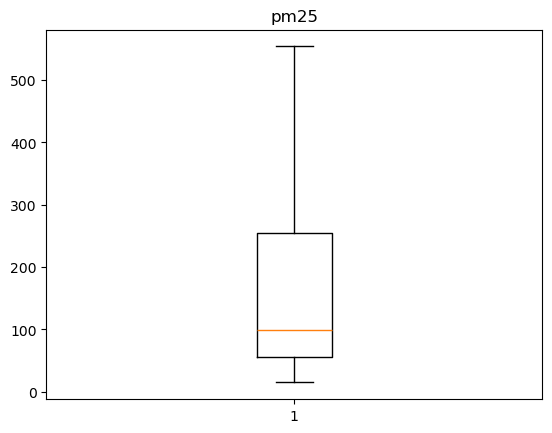

lf :  -461.55000000000007
uf : 1046.8500000000001


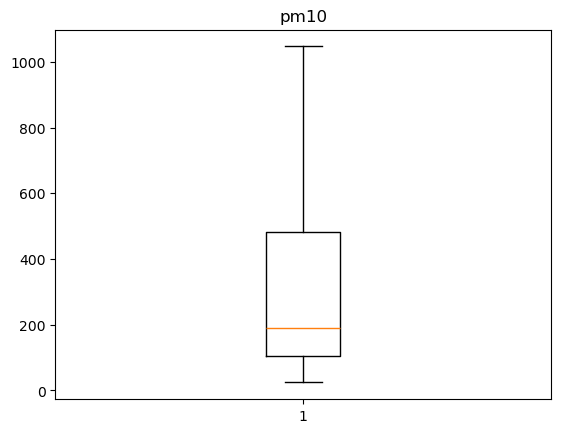

lf :  -91.25
uf : 205.14999999999998


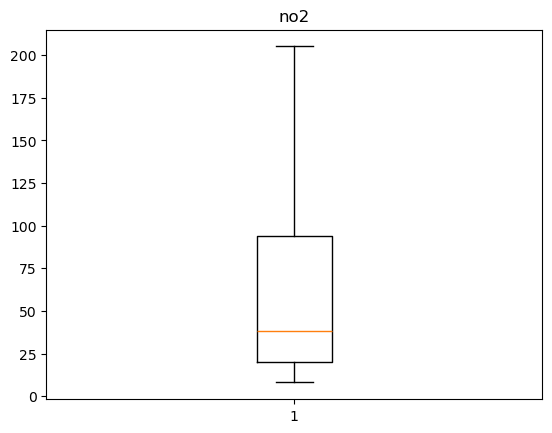

lf :  -20.099999999999998
uf : 45.5


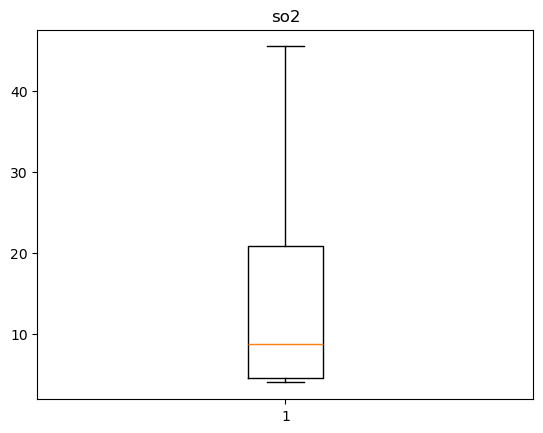

lf :  -4.005
uf : 8.995000000000001


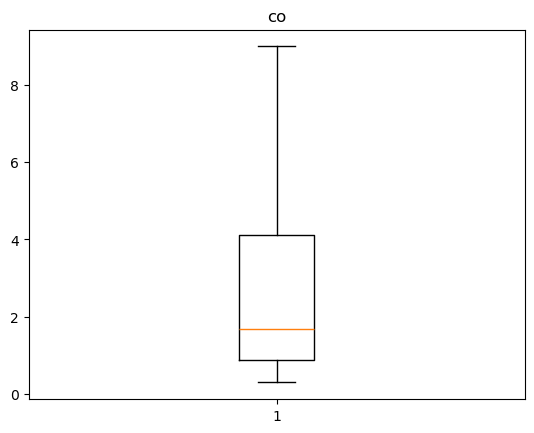

lf :  -2.700000000000003
uf : 52.5


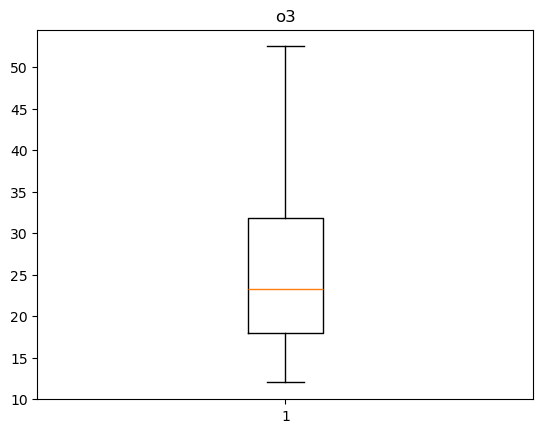

lf :  -6.549999999999999
uf : 26.65


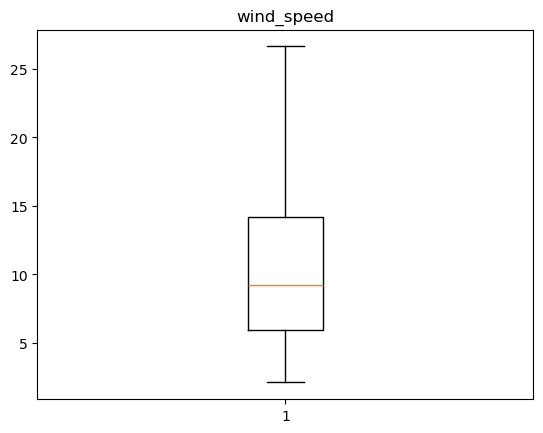

lf :  -5.899999999999999
uf : 14.899999999999999


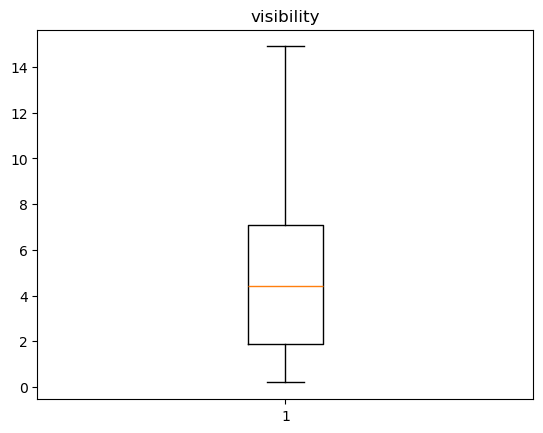

In [7]:
for i in df.select_dtypes(float):
    if ((i != "latitude") and (i != "longitude") and (i != "temperature")):
            q1 = df[i].quantile(0.25)
            q3 = df[i].quantile(0.75)
            iqr = q3 - q1
            lf = q1 - (1.5*iqr)
            uf = q3 + (1.5*iqr)
            print("lf : ",lf)
            print("uf :",uf)
            df[i] = np.where(df[i] > uf, uf, df[i])
            df[i] = np.where(df[i] < lf, lf, df[i])
            plt.title(i)
            plt.boxplot(df[i])
            plt.show()

In [8]:
df = pd.get_dummies(df, columns = ["day_of_week", "season"])

In [9]:
df = df.sort_values(['year', 'month', 'day', 'hour'])

In [10]:
x = df.drop(columns=["aqi"])
y = df["aqi"]

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.3, random_state = 88)

In [22]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)
print("Training R square : ",lr.score(x_train,y_train))
print("Testing R square : ",lr.score(x_test,y_test))
print("Training RMSE : ",root_mean_squared_error(y_train,lr.predict(x_train)))
print("Testing RMSE : ",root_mean_squared_error(y_test,lr.predict(x_test)))

Training R square :  0.957595676410749
Testing R square :  0.9568902608945041
Training RMSE :  35.32009566458031
Testing RMSE :  35.6041622561434


In [13]:
dt = DecisionTreeRegressor(random_state = 88)
dt.fit(x_train,y_train)
print(f"Training R square is : {dt.score(x_train,y_train)}")
print(f"Testing R square is : {dt.score(x_test,y_test)}")
print(f"Testing RMSE : {root_mean_squared_error(y_train,dt.predict(x_train))}")
print(f"Testing RMSE : {root_mean_squared_error(y_test,dt.predict(x_test))}")

Training R square is : 1.0
Testing R square is : 0.999999930298815
Testing RMSE : 0.0
Testing RMSE : 0.045272362174504484
